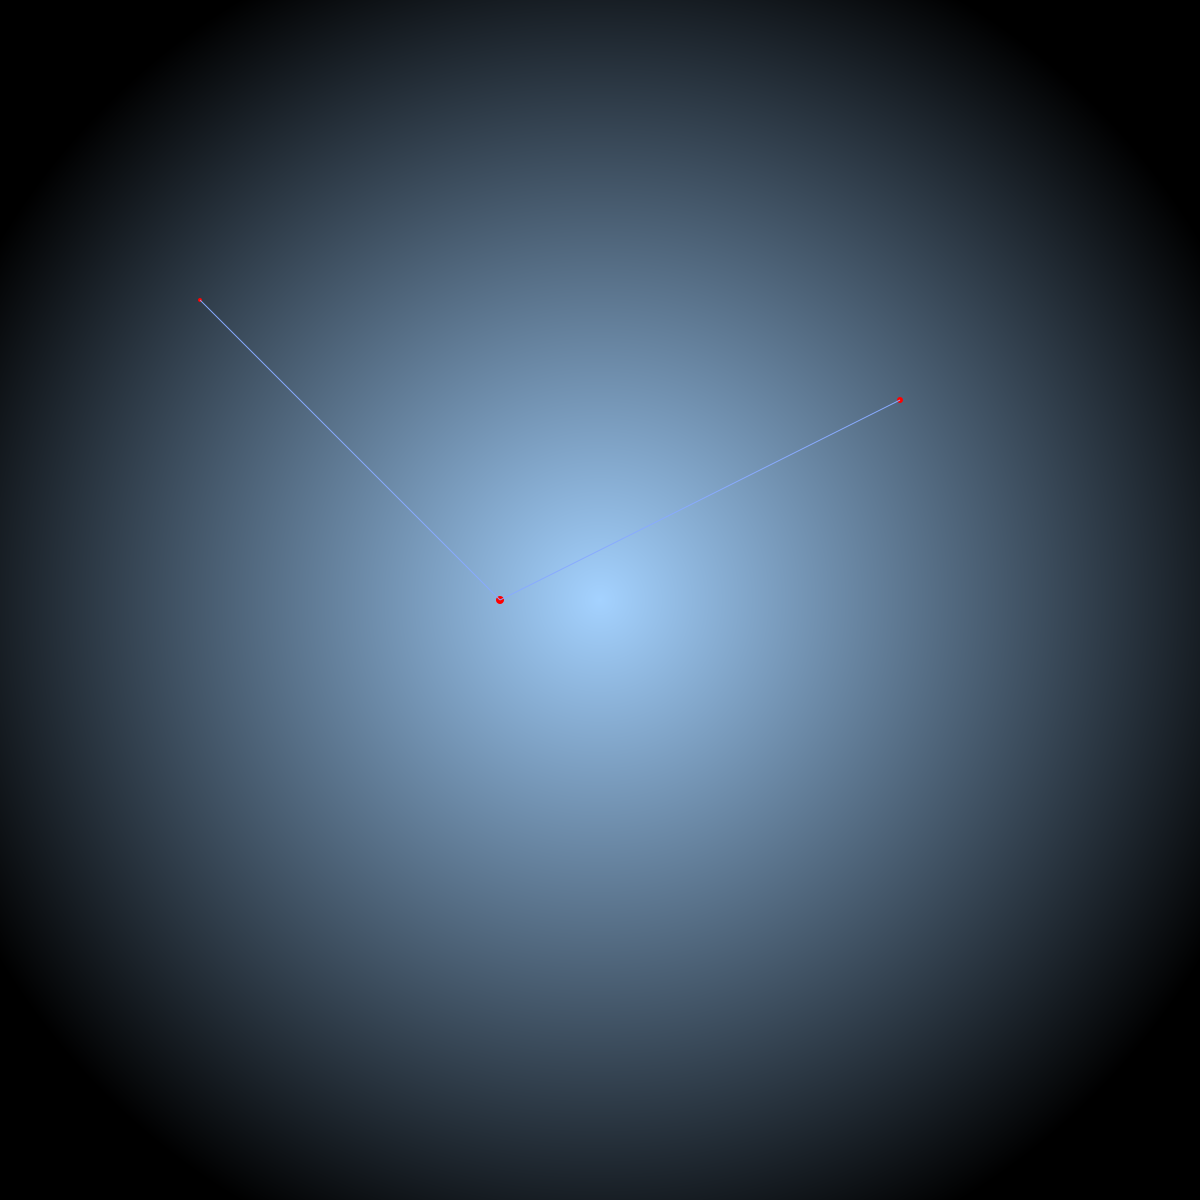

In [74]:
import drawsvg as draw

d = draw.Drawing(1200, 1200)

# Background gradient
grad = draw.RadialGradient(600, 600, 700)
grad.add_stop(0, "#A4D2FF")
grad.add_stop(1, '#000000')

d.append(draw.Rectangle(
    0, 0, 1200, 1200,
    fill=grad
))

# Star positions
stars = [
    (200, 300, 2),
    (500, 600, 4),
    (900, 400, 3),
]

# Draw stars
for x, y, r in stars:
    d.append(draw.Circle(
        x, y, r,
        fill='red'
    ))

# Constellation lines
lines = [
    ((200, 300), (500, 600)),
    ((500, 600), (900, 400)),
]

for (x1, y1), (x2, y2) in lines:
    d.append(draw.Line(
        x1, y1,
        x2, y2,
        stroke='#88aaff',
        stroke_width=1
    ))

d.save_svg('chart.svg')
d

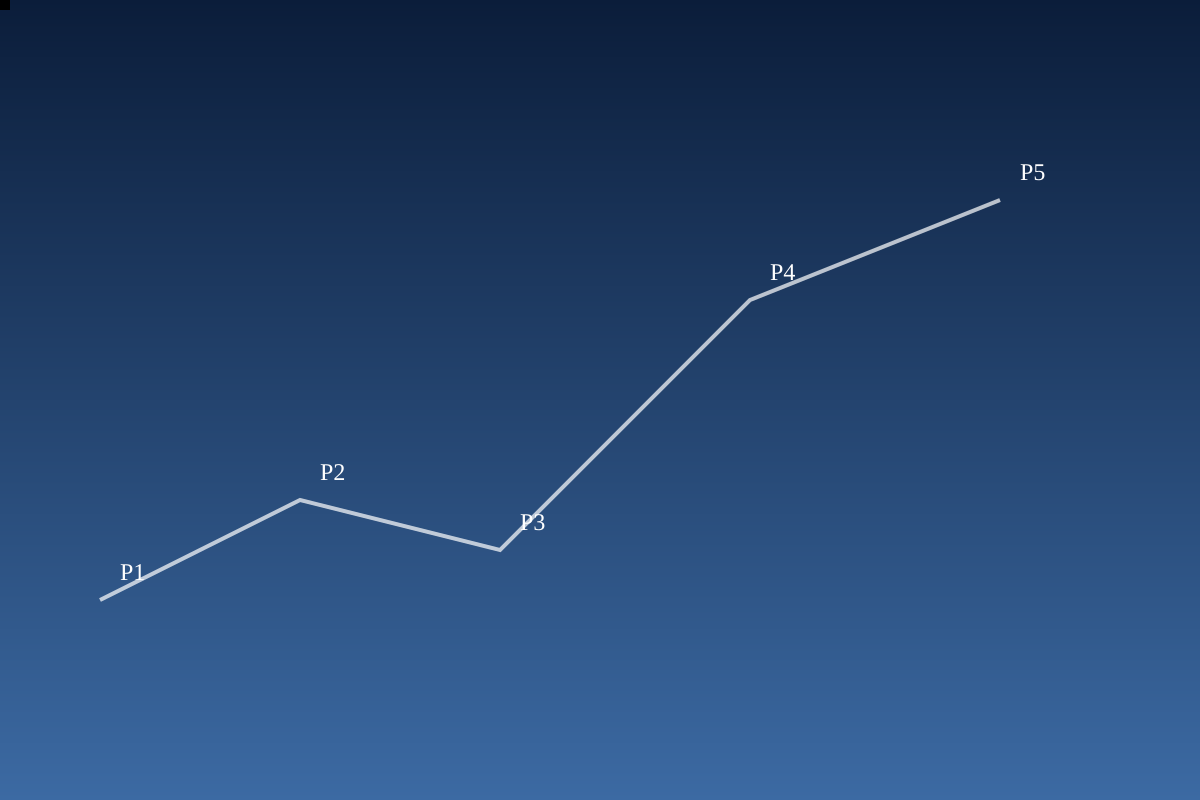

In [18]:
import drawsvg as draw
import xml.etree.ElementTree as ET

# ------------------------------------------------------------
# Load SVG and extract layers
# ------------------------------------------------------------

svg_file = 'rect1.svg'
tree = ET.parse(svg_file)
root = tree.getroot()

ns = {'svg': 'http://www.w3.org/2000/svg'}

layers = {}

for g in root.findall('svg:g', ns):
    layer_id = g.attrib.get('id')

    group = draw.Group(id=layer_id)

    # Convert children manually (simple shapes only here)
    for elem in g:
        tag = elem.tag.split('}')[-1]

        if tag == 'rect':
            group.append(draw.Rectangle(
                float(elem.attrib['x']),
                float(elem.attrib['y']),
                float(elem.attrib['width']),
                float(elem.attrib['height']),
                fill=elem.attrib.get('style', '#000000')
            ))

        elif tag == 'circle':
            group.append(draw.Circle(
                float(elem.attrib['cx']),
                float(elem.attrib['cy']),
                float(elem.attrib['r']),
                fill=elem.attrib.get('style', '#000000')
            ))

        elif tag == 'path':
            group.append(draw.Path(
                d=elem.attrib['d'],
                fill=elem.attrib.get('style', '#000000')
            ))

    layers[layer_id] = group

# ------------------------------------------------------------
# Drawing
# ------------------------------------------------------------

W, H = 1200, 800
d = draw.Drawing(W, H)

# Background gradient
grad = draw.LinearGradient(0, 0, 0, H)
grad.add_stop(0, '#0b1d3a')
grad.add_stop(1, '#3c6aa3')

d.append(draw.Rectangle(0, 0, W, H, fill=grad))

# ------------------------------------------------------------
# Add layers to defs (THIS is correct drawsvg usage)
# ------------------------------------------------------------

for layer in layers.values():
    d.append(layer)  # IMPORTANT: groups with id go into defs automatically

# ------------------------------------------------------------
# Marker helper (layer toggle supported)
# ------------------------------------------------------------

def add_marker(x, y, scale=5, layers=('layer1', 'layer2')):
    for layer in layers:
        d.append(draw.Use(
            f'#{layer}',
            x=x,
            y=y,
            transform=f'scale({scale})'
        ))

# ------------------------------------------------------------
# Example points
# ------------------------------------------------------------

points = [
    (100, 600),
    (300, 500),
    (500, 550),
    (750, 300),
    (1000, 200),
]

# Connecting line
path = draw.Path(stroke='white', stroke_width=4, fill='none', opacity=0.7)
path.M(*points[0])
for p in points[1:]:
    path.L(*p)
d.append(path)

# ------------------------------------------------------------
# Markers (layer3 = highlight toggle)
# ------------------------------------------------------------

add_marker(100, 600, layers=('layer1', 'layer2'))
add_marker(300, 500, layers=('layer1', 'layer2', 'layer3'))
add_marker(500, 550, layers=('layer1', 'layer2'))
add_marker(750, 300, layers=('layer1', 'layer2', 'layer3'))
add_marker(1000, 200, layers=('layer1', 'layer2'))

# Labels
for i, (x, y) in enumerate(points):
    d.append(draw.Text(f'P{i+1}', 24, x+20, y-20, fill='white'))

# Save
d.save_svg('example.svg')
d

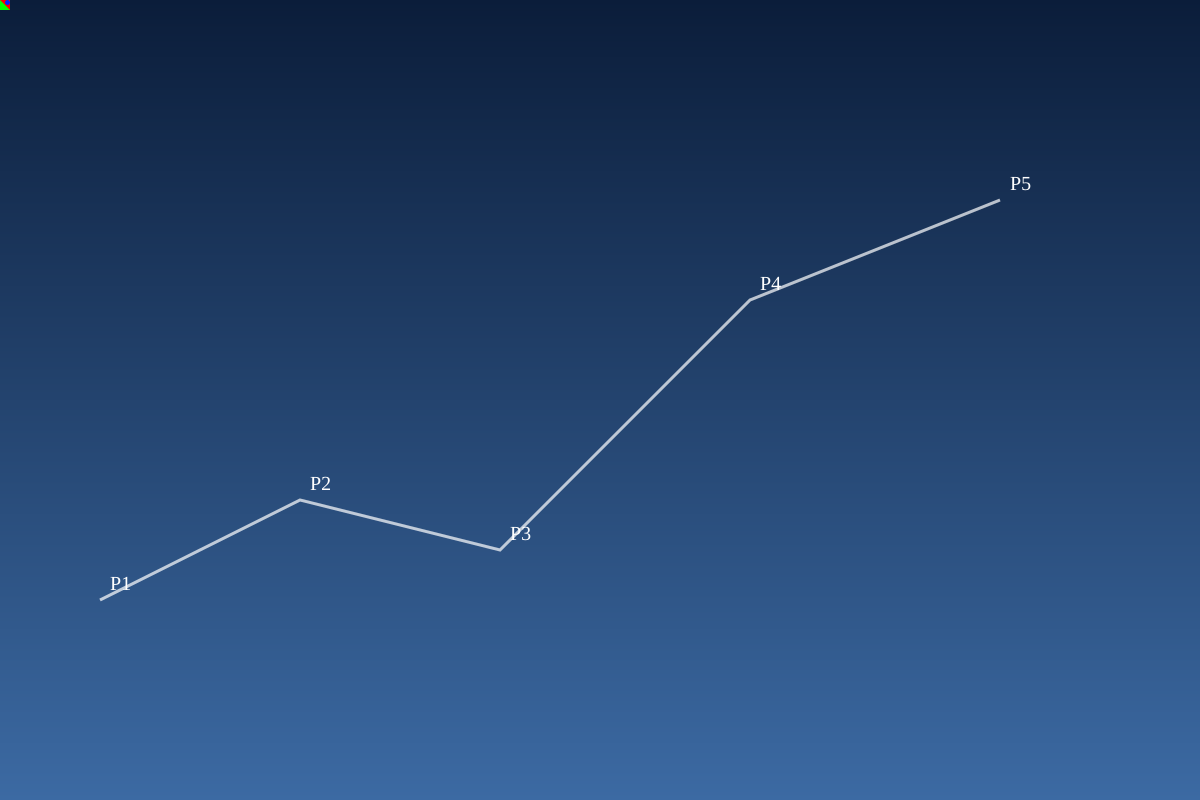

In [21]:
import drawsvg as draw
import xml.etree.ElementTree as ET

# ------------------------------------------------------------
# Parse SVG layers
# ------------------------------------------------------------

svg_file = "rect1.svg"
tree = ET.parse(svg_file)
root = tree.getroot()

ns = {'svg': 'http://www.w3.org/2000/svg'}

layers = {}

for g in root.findall('svg:g', ns):
    layer_id = g.attrib['id']

    group = draw.Group(id=layer_id)

    for elem in g:
        tag = elem.tag.split('}')[-1]

        style = elem.attrib.get('style', '')

        # VERY IMPORTANT: extract fill correctly
        fill = None
        if "fill:" in style:
            fill = style.split("fill:")[1].split(";")[0]

        if tag == "rect":
            group.append(draw.Rectangle(
                float(elem.attrib['x']),
                float(elem.attrib['y']),
                float(elem.attrib['width']),
                float(elem.attrib['height']),
                fill=fill
            ))

        elif tag == "circle":
            group.append(draw.Circle(
                float(elem.attrib['cx']),
                float(elem.attrib['cy']),
                float(elem.attrib['r']),
                fill=fill
            ))

        elif tag == "path":
            group.append(draw.Path(
                d=elem.attrib['d'],
                fill=fill
            ))

    layers[layer_id] = group

# ------------------------------------------------------------
# Drawing
# ------------------------------------------------------------

W, H = 1200, 800
d = draw.Drawing(W, H)

# background gradient
grad = draw.LinearGradient(0, 0, 0, H)
grad.add_stop(0, "#0b1d3a")
grad.add_stop(1, "#3c6aa3")

d.append(draw.Rectangle(0, 0, W, H, fill=grad))

# ------------------------------------------------------------
# IMPORTANT: register groups (this is enough in drawsvg)
# ------------------------------------------------------------

for g in layers.values():
    d.append(g)

# ------------------------------------------------------------
# Marker system using GROUP REFERENCES (no defs needed)
# ------------------------------------------------------------

def add_marker(x, y, layers_to_use, scale=5):
    for layer_id in layers_to_use:
        d.append(draw.Use(
            f"#{layer_id}",
            x=x,
            y=y,
            transform=f"scale({scale})"
        ))

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

points = [
    (100, 600),
    (300, 500),
    (500, 550),
    (750, 300),
    (1000, 200),
]

# lines between markers
path = draw.Path(stroke="white", stroke_width=3, fill="none", opacity=0.7)
path.M(*points[0])
for p in points[1:]:
    path.L(*p)

d.append(path)

# ------------------------------------------------------------
# Markers (layer3 = highlight toggle)
# ------------------------------------------------------------

add_marker(100, 600, ("layer1", "layer2"))
add_marker(300, 500, ("layer1", "layer2", "layer3"))
add_marker(500, 550, ("layer1", "layer2"))
add_marker(750, 300, ("layer1", "layer2", "layer3"))
add_marker(1000, 200, ("layer1", "layer2"))

# labels
for i, (x, y) in enumerate(points):
    d.append(draw.Text(f"P{i+1}", 20, x+10, y-10, fill="white"))

d.save_svg("example.svg")
d

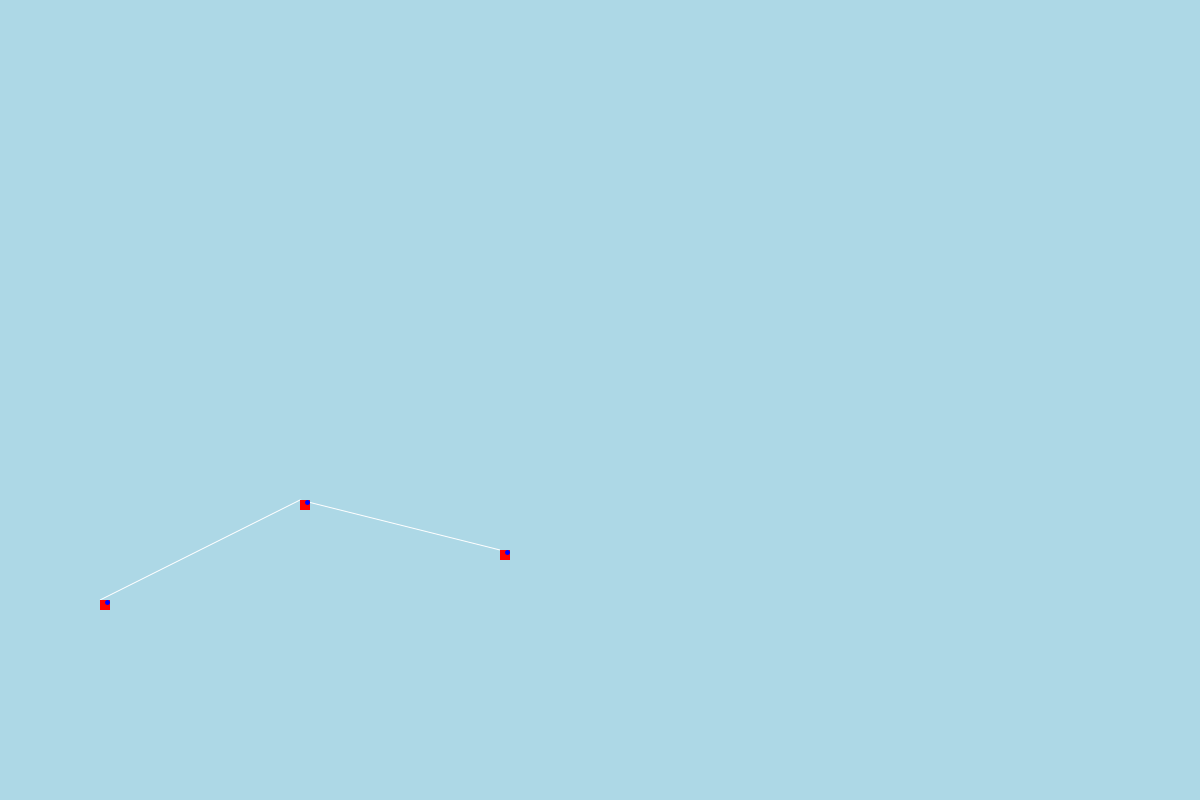

In [23]:
import svgwrite

dwg = svgwrite.Drawing("test.svg", size=(1200, 800))

# defs + symbol
symbol = dwg.symbol(id="marker", viewBox="0 0 10 10")
symbol.add(dwg.rect((0, 0), (10, 10), fill="red"))
symbol.add(dwg.circle(center=(7.5, 2.5), r=2.5, fill="blue"))
dwg.defs.add(symbol)

# background
dwg.add(dwg.rect((0, 0), (1200, 800), fill="lightblue"))

# line
points = [(100, 600), (300, 500), (500, 550)]
dwg.add(dwg.polyline(points, stroke="white", fill="none"))

# markers
for x, y in points:
    dwg.add(dwg.use("#marker", insert=(x, y), size=(10, 10)))

dwg.save()
dwg

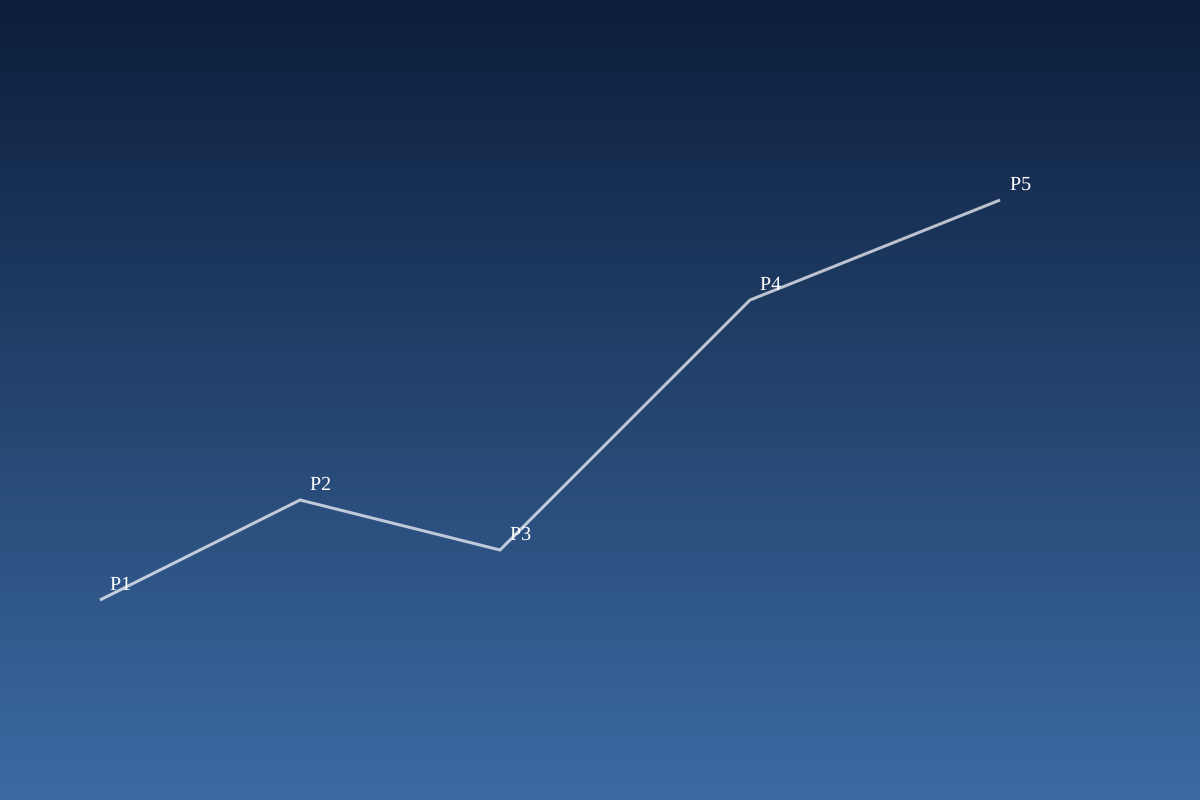

In [37]:
import svgwrite
import xml.etree.ElementTree as ET

# ------------------------------------------------------------
# Load Inkscape SVG and extract layers
# ------------------------------------------------------------

svg_file = "rect1.svg"

tree = ET.parse(svg_file)
root = tree.getroot()

ns = {"svg": "http://www.w3.org/2000/svg"}

layers = {}

for g in root.findall("svg:g", ns):
    layer_id = g.attrib["id"]

    # store raw group XML content
    layers[layer_id] = g

# ------------------------------------------------------------
# Create drawing
# ------------------------------------------------------------

W, H = 1200, 800
dwg = svgwrite.Drawing("example.svg", size=(W, H))

# ------------------------------------------------------------
# Background gradient
# ------------------------------------------------------------

grad = dwg.linearGradient(start=(0, 0), end=(0, 1), id="bggrad")
grad.add_stop_color(0, "#0b1d3a")
grad.add_stop_color(1, "#3c6aa3")
dwg.defs.add(grad)

dwg.add(dwg.rect(insert=(0, 0), size=(W, H), fill="url(#bggrad)"))

# ------------------------------------------------------------
# Convert each layer into a SYMBOL (THIS is the key fix)
# ------------------------------------------------------------

def convert_layer_to_symbol(layer_elem, symbol_id):

    # ------------------------------------------------------------
    # 1. read original bounds (assumes 0..10 if Inkscape)
    # ------------------------------------------------------------

    min_x, min_y = 0, 0
    max_x, max_y = 10, 10

    cx = (min_x + max_x) / 2
    cy = (min_y + max_y) / 2

    scale = 2.0 / max(max_x - min_x, max_y - min_y)

    # ------------------------------------------------------------
    # 2. create normalized symbol
    # ------------------------------------------------------------

    symbol = dwg.symbol(id=symbol_id, viewBox="-1 -1 2 2")

    for child in layer_elem:
        tag = child.tag.split("}")[-1]
        style = child.attrib.get("style", "")

        fill = None
        if "fill:" in style:
            fill = style.split("fill:")[1].split(";")[0]

        # --------------------------------------------------------
        # RECT
        # --------------------------------------------------------
        if tag == "rect":
            x = float(child.attrib["x"])
            y = float(child.attrib["y"])
            w = float(child.attrib["width"])
            h = float(child.attrib["height"])

            # normalize center
            x = (x - cx) * scale
            y = (y - cy) * scale
            w = w * scale
            h = h * scale

            symbol.add(dwg.rect((x, y), (w, h), fill=fill))

        # --------------------------------------------------------
        # CIRCLE
        # --------------------------------------------------------
        elif tag == "circle":
            x = float(child.attrib["cx"])
            y = float(child.attrib["cy"])
            r = float(child.attrib["r"])

            x = (x - cx) * scale
            y = (y - cy) * scale
            r = r * scale

            symbol.add(dwg.circle((x, y), r, fill=fill))

        # --------------------------------------------------------
        # PATH (kept raw but scaled via transform)
        # --------------------------------------------------------
        elif tag == "path":
            symbol.add(
                dwg.path(
                    d=child.attrib["d"],
                    fill=fill,
                    transform=f"translate({-cx}, {-cy}) scale({scale})"
                )
            )

    dwg.defs.add(symbol)

# create symbols
for layer_id, elem in layers.items():
    convert_layer_to_symbol(elem, layer_id)

# ------------------------------------------------------------
# Optional: combine layers into marker presets
# ------------------------------------------------------------

# base marker
dwg.defs.add(dwg.symbol(
    id="marker_base",
    viewBox="-1 -1 2 2"
))

# highlight marker (includes layer3)
dwg.defs.add(dwg.symbol(
    id="marker_highlight",
    viewBox="-1 -1 2 2"
))

# NOTE:
# svgwrite does not auto-compose symbols,
# so we instead just reuse layers directly below.

# ------------------------------------------------------------
# Points
# ------------------------------------------------------------

points = [
    (100, 600),
    (300, 500),
    (500, 550),
    (750, 300),
    (1000, 200),
]

# ------------------------------------------------------------
# Connecting line
# ------------------------------------------------------------

dwg.add(dwg.polyline(
    points,
    stroke="white",
    fill="none",
    stroke_width=3,
    opacity=0.7
))

# ------------------------------------------------------------
# Marker drawing function
# ------------------------------------------------------------

def add_marker(x, y, highlight=False, scale=5):

    # base layers
    for layer in ["layer1", "layer2"]:
        dwg.add(dwg.use(
            f"#{layer}",
            insert=(x, y),
            transform=f"scale({scale})"
        ))

    # optional highlight layer
    if highlight:
        dwg.add(dwg.use(
            "#layer3",
            insert=(x, y),
            transform=f"scale({scale})"
        ))

# ------------------------------------------------------------
# Render markers
# ------------------------------------------------------------

add_marker(100, 600)
add_marker(300, 500, highlight=True)
add_marker(500, 550)
add_marker(750, 300, highlight=True)
add_marker(1000, 200)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

for i, (x, y) in enumerate(points):
    dwg.add(dwg.text(
        f"P{i+1}",
        insert=(x + 10, y - 10),
        fill="white",
        font_size="20px"
    ))

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

dwg.save()
dwg

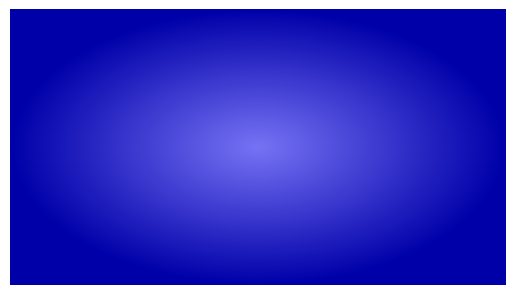

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    return np.array([int(hex_color[i:i+2], 16) for i in (0, 2, 4)]) / 255.0

fig, ax = plt.subplots()

w, h = 900, 500

# coordinate grid (centered)
y = np.linspace(-1, 1, h)[:, None]
x = np.linspace(-1, 1, w)[None, :]

# ellipse shape control (auto-fit to rectangle)
aspect = w / h
r = np.sqrt(x**2 + (y)**2)
r = np.clip(r, 0, 1)

# HEX colors
center_hex = "#7773F5"
edge_hex   = "#0000A9"

c1 = hex_to_rgb(center_hex)
c2 = hex_to_rgb(edge_hex)

# blend
img = (1 - r)[..., None] * c1 + r[..., None] * c2

ax.imshow(img, origin="lower")
ax.axis("off")
ax.set_aspect('equal')

plt.show()

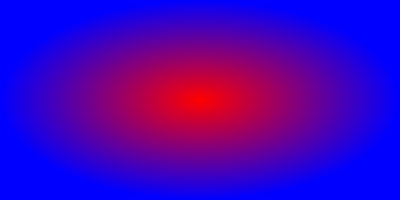

In [44]:
import svgwrite

dwg = svgwrite.Drawing("gradient.svg", size=("400px", "200px"))

grad = dwg.radialGradient()
grad.add_stop_color(0, "#ff0000")
grad.add_stop_color(1, "#0000ff")

dwg.defs.add(grad)

dwg.add(dwg.rect(insert=(0, 0), size=("400px", "200px"), fill=grad.get_paint_server()))

dwg.save()
dwg

# YAML importing example

In [59]:
import yaml

with open("card_formats.yaml", 'r') as file:
    data = yaml.safe_load(file)

# Now 'data' is a Python dictionary
print(data['tarot'])


{'height': 4.75, 'width': 2.75, 'pad': 0.25, 'text_x': 0.4, 'text_y': 3.6, 'box_width': 1.95, 'box_height': 0.8, 'max_font_scale': 3, 'round': {'box_style': "f'round, pad:0.0, rounding_size:0.2'", 'text_box_style': 'round, pad : 0.2, rounding_size:0.3', 'default_cardback_file': 'cardbacks/tarot_round.png'}, 'square': {'box_style': 'square, pad:0.0', 'text_box_style': 'round, pad : 0.2, rounding_size:0.05', 'default_cardback_file': 'cardbacks/tarot_square.png'}}


In [61]:
'round' in data['circle'].keys()

False

# SVG read multiple layers

In [173]:
from svgpathtools import svg2paths
from svgpath2mpl import parse_path
import numpy as np


def load_svg_path(file):
    _, attributes, *_ = svg2paths(file)
    base_path = parse_path(attributes[3]['d'])
    vertices = np.array(base_path.vertices)
    # Translate the path to be centered in 0 and scaled to 1
    offset = (vertices.max(axis=0) + vertices.min(axis=0))/2
    scale = 1 / (vertices.max(axis=0) - vertices.min(axis=0)).max()

    markers = []
    for attribute in attributes:
        path = parse_path(attribute['d'])
        path.vertices -= offset
        path.vertices[:,1] *= -1
        path.vertices *= scale
        markers.append(path)
    
    return markers

markers = load_svg_path('star.svg')

In [174]:
len(markers)

7

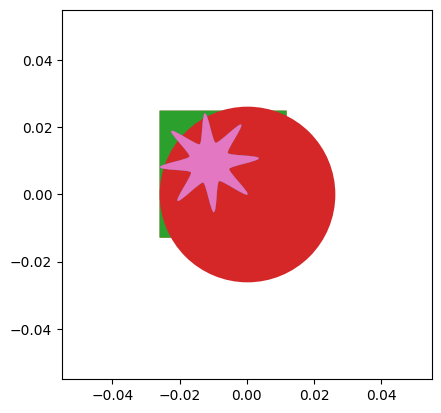

In [175]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set_aspect('equal')
for marker in markers:
    ax.scatter(0,0, s=16000, marker=marker, lw=0)
plt.show()

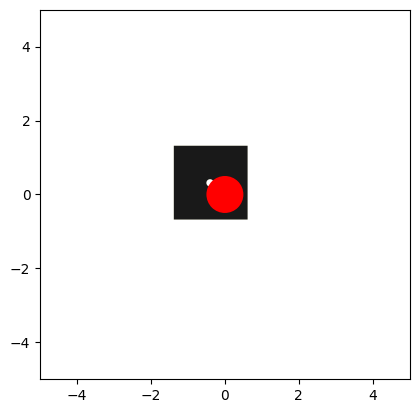

In [178]:
from matplotlib.patches import PathPatch

fig, ax = plt.subplots()

glow = PathPatch(markers[0], alpha=0.2, ec='none', fc='yellow')
star = PathPatch(markers[1], ec='none', fc='white')
shadow = PathPatch(markers[2], alpha=0.9, ec='none', fc='black')
high = PathPatch(markers[3], ec='none', fc='red')

ax.add_patch(glow)
ax.add_patch(star)
ax.add_patch(shadow)
ax.add_patch(high)


ax.set_xlim(-5,5)
ax.set_ylim(-5,5)

ax.set_aspect('equal')
plt.show()

In [83]:
import numpy as np
from matplotlib.collections import PathCollection
from matplotlib.colors import to_rgba
from matplotlib.transforms import Affine2D


def plot_stars(
    ax,
    x,
    y,
    s,
    star_colors="white",
    glow_colors="yellow",
    shadow_color="black",
    highlight_color="red",
    glow_alpha=0.2,
    shadow_alpha=0.9,
):
    """
    Draw stars using PathCollections.

    Parameters
    ----------
    x, y : array-like
        Positions.
    s : scalar or array-like
        Linear scale factor.

    star_colors : color or sequence of colors
        One color per star or a single color.

    glow_colors : color or sequence of colors
        One color per glow or a single color.
    """

    x = np.atleast_1d(x)
    y = np.atleast_1d(y)
    s = np.atleast_1d(s)

    n = len(x)

    if len(y) != n:
        raise ValueError("x and y must have same length")

    if len(s) == 1:
        s = np.full(n, s[0])

    offsets = np.column_stack((x, y))

    def expand_colors(colors, n, alpha=None):
        if isinstance(colors, str) or not hasattr(colors, "__len__"):
            colors = [colors] * n

        rgba = np.array([to_rgba(c, alpha=alpha) for c in colors])

        if len(rgba) != n:
            raise ValueError("Color array length mismatch")

        return rgba

    star_rgba = expand_colors(star_colors, n)
    glow_rgba = expand_colors(glow_colors, n, alpha=glow_alpha)


    def make_collection(path, colors, alpha=None, sizes=1):
        coll = PathCollection(
            [path],
            offsets=offsets,
            transOffset=ax.transData,
            facecolors=colors,
            edgecolors="none",
            alpha=alpha,
            sizes = [sizes]
        )

        ax.add_collection(coll)
        return coll

    glow = make_collection(markers[0], glow_rgba, sizes=s)
    star = make_collection(markers[1], star_rgba, sizes=s)

    shadow = make_collection(
        markers[2],
        [to_rgba(shadow_color)],
        alpha=shadow_alpha,
    )

    high = make_collection(
        markers[3],
        [to_rgba(highlight_color)],
    )

    return glow, star, shadow, high

In [92]:
[*zip(x,y)]

[(0, 0), (1, -1), (2, 0), (3, 1)]

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def fancy_line(x, y,
               jitter=0.02,
               wiggle=0.15,
               n_subdivide=8,
               cmap="viridis",
               lw=2):

    x = np.asarray(x)
    y = np.asarray(y)

    # --------------------------------------------------
    # 1. Subdivide line (more points = smoother squiggle)
    # --------------------------------------------------
    t = np.linspace(0, 1, len(x))
    t_new = np.linspace(0, 1, len(x) * n_subdivide)

    x_new = np.interp(t_new, t, x)
    y_new = np.interp(t_new, t, y)

    # --------------------------------------------------
    # 2. Add smooth "hand-drawn" wiggle (perpendicular noise)
    # --------------------------------------------------
    dx = np.gradient(x_new)
    dy = np.gradient(y_new)
    norm = np.sqrt(dx**2 + dy**2) + 1e-9

    # perpendicular vectors
    nx = -dy / norm
    ny = dx / norm

    noise = np.sin(np.linspace(0, 8*np.pi, len(x_new))) * wiggle
    noise += np.random.normal(scale=jitter, size=len(x_new))

    x_new = x_new + nx * noise
    y_new = y_new + ny * noise

    # --------------------------------------------------
    # 3. Build colored segments (gradient line)
    # --------------------------------------------------
    points = np.array([x_new, y_new]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    color_values = np.linspace(0, 1, len(segments))

    lc = LineCollection(segments, cmap=cmap, array=color_values,
                        linewidth=lw, capstyle="round")

    return lc

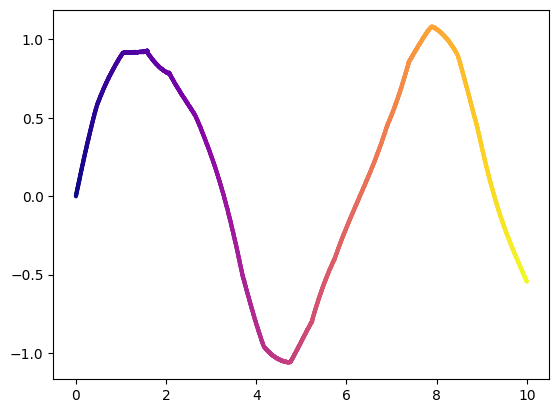

In [57]:
x = np.linspace(0, 10, 20)
y = np.sin(x)

fig, ax = plt.subplots()

line = fancy_line(x, y,
                  jitter=0.001,
                  wiggle=0.1,
                  cmap="plasma",
                  lw=3, n_subdivide=100)

ax.add_collection(line)
ax.autoscale()
ax.set_aspect("auto")

plt.show()

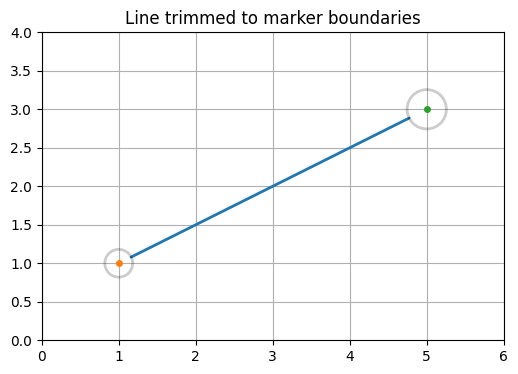

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Data
# ------------------------------------------------------------------
A = np.array([1.0, 1.0])
B = np.array([5.0, 3.0])

# scatter marker size (same meaning as plt.scatter(..., s=...))
s = 400

# ------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.set_aspect('equal')
# Set limits BEFORE computing transforms
ax.set_xlim(0, 6)
ax.set_ylim(0, 4)

# Force creation of transforms
fig.canvas.draw()


def shorten_line(A,B,s1,s2):

    s2px = lambda s: np.sqrt(s) * fig.dpi / 144
    # ------------------------------------------------------------------
    # Compute shortened line endpoints in DISPLAY coordinates
    # ------------------------------------------------------------------
    A_disp = ax.transData.transform(A)
    B_disp = ax.transData.transform(B)

    direction = B_disp - A_disp
    distance = np.linalg.norm(direction)

    unit = direction / distance

    P1_disp = A_disp + s2px(s1) * unit
    P2_disp = B_disp - s2px(s2) * unit

    # Convert back to data coordinates
    P1 = ax.transData.inverted().transform(P1_disp)
    P2 = ax.transData.inverted().transform(P2_disp)

    return P1, P2

P1, P2 = shorten_line(A, B, 400, 800)

ax.plot(
    [P1[0], P2[0]],
    [P1[1], P2[1]],
    lw=2, solid_capstyle="round"
)

# ------------------------------------------------------------------
# Draw empty circles
# ------------------------------------------------------------------
ax.scatter(
    [A[0], B[0]],
    [A[1], B[1]],
    s=(400,800),
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    zorder=3, 
    alpha=0.2
)

# Optional: show centers
ax.plot(A[0], A[1], ".", ms=8)
ax.plot(B[0], B[1], ".", ms=8)

ax.set_title("Line trimmed to marker boundaries")
ax.grid(True)

plt.show()

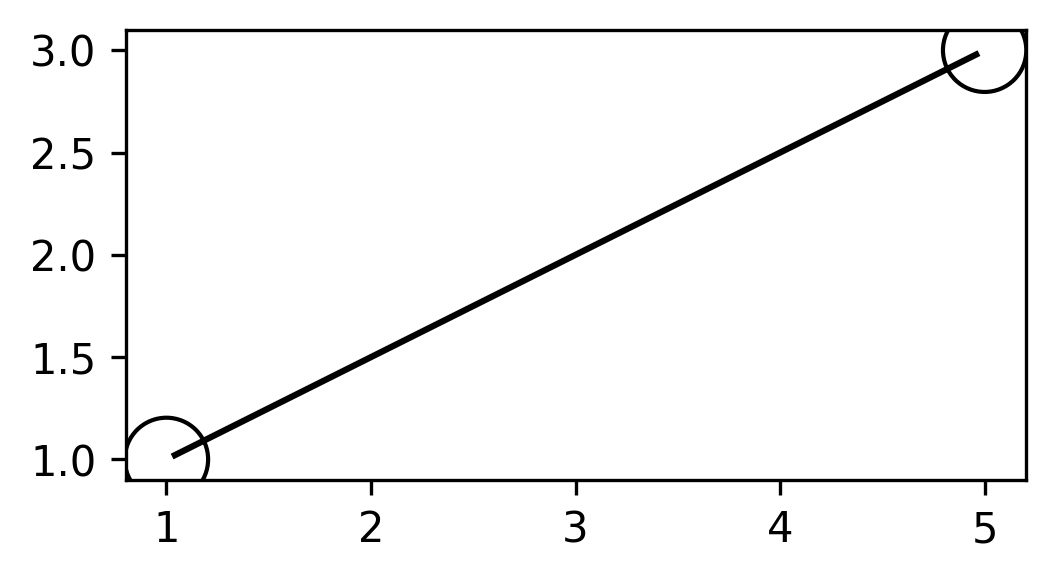

In [13]:
import numpy as np
import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize = (3,3), dpi=300) #figure with correct aspect ratio
fig.subplots_adjust(0,0,1,1)
ax.set_aspect('equal')

A = np.array([1.0, 1.0])
B = np.array([5.0, 3.0])

s = 400

# draw once so transforms exist
fig.canvas.draw()

# marker radius in points
r_pt = np.sqrt(s) / 2

# convert to pixels
r_px = r_pt * fig.dpi / 72

# convert pixels -> data units
p0 = ax.transData.transform((0, 0))
p1 = ax.transData.transform((1, 0))

px_per_data = p1[0] - p0[0]

r_data = r_px / px_per_data

# direction vector
d = B - A
u = d / np.linalg.norm(d)

# shorten line
P1 = A + r_data * u
P2 = B - r_data * u

# line
ax.plot(
    [P1[0], P2[0]],
    [P1[1], P2[1]],
    'k-'
)

# empty circles
ax.scatter(
    [A[0], B[0]],
    [A[1], B[1]],
    s=s,
    facecolors='none',
    edgecolors='k'
)

plt.show()

In [157]:
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D


def build_compound_layer(base_path, x, y, s):
    """
    Build a single compound Path containing all transformed copies
    of base_path in DATA coordinates.
    """
    paths = []

    for xi, yi, si in zip(x, y, s):
        transform = Affine2D().scale(si).translate(xi, yi)
        paths.append(transform.transform_path(base_path))

    return Path.make_compound_path(*paths)


def plot_stars(
    ax,
    x,
    y,
    s,
    markers,
    glow_color="yellow",
    star_color="white",
    shadow_color="black",
    highlight_color="red",
    glow_alpha=0.2,
    shadow_alpha=0.9,
):

    x = np.asarray(x)
    y = np.asarray(y)
    s = np.asarray(s)

    def add_layer(base_path, color, alpha=1.0):
        compound = build_compound_layer(base_path, x, y, s)

        patch = PathPatch(
            compound,
            facecolor=color,
            edgecolor="none",
            alpha=alpha
        )

        ax.add_patch(patch)
        return patch

    glow = add_layer(markers[0], glow_color, glow_alpha)
    star = add_layer(markers[1], ['red', 'blue', 'green', 'red'], 1.0)
    shadow = add_layer(markers[2], shadow_color, shadow_alpha)
    highlight = add_layer(markers[3], highlight_color, 1.0)

    return glow, star, shadow, highlight

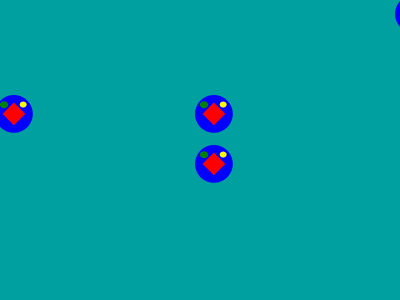

In [15]:
import drawsvg as draw
from svgelements import SVG

def add_svg_centered(drawing, filename, x, y, width, height):
    svg = SVG.parse(filename)

    viewbox_w = 10
    viewbox_h = 10

    sx = width / viewbox_w
    sy = height / viewbox_h

    g = draw.Group(
        transform=(
            f'translate({x},{y}) '
            f'scale({sx},{sy}) '
            f'translate({-viewbox_w/2},{-viewbox_h/2})'
        )
    )

    for elem in svg.elements():
        if hasattr(elem, 'd'):
            g.append(
                draw.Path(
                    d=elem.d(),
                    fill=elem.fill.hex if elem.fill else 'none'
                )
            )

    drawing.append(g)

d = draw.Drawing(400, 300)
d.append(draw.Rectangle(0, 0, 400, 300, fill='#00A0A0'))

# center at (200,150)
add_svg_centered(
    d,
    'rect1.svg',
    x=200,
    y=150,
    width=10,
    height=10,
)

add_svg_centered(
    d,
    'rect1.svg',
    x=200,
    y=100,
    width=10,
    height=10,
)

add_svg_centered(d,'rect1.svg', x=400, y=000, width=10, height=10)
add_svg_centered(d,'rect1.svg', x=000, y=100, width=10, height=10)

d.save_svg('result.svg')
d

# SVG ICON LOADER WORKING

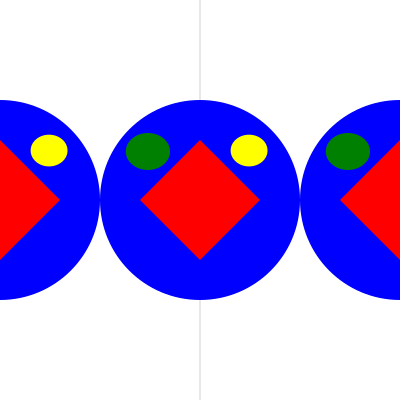

In [3]:
import drawsvg as draw
from svgelements import SVG


def load_normalized_svg(filename):
    """
    Load an SVG and return a drawsvg.Group whose:
      - visual center is at (0, 0)
      - visual width is 1
      - aspect ratio is preserved

    The normalization is based on the actual geometry bounding box,
    not the SVG viewBox, so it removes any Inkscape margins.
    """
    svg = SVG.parse(filename)

    elements = []

    xmin = float("inf")
    ymin = float("inf")
    xmax = float("-inf")
    ymax = float("-inf")

    for elem in svg.elements():
        if not hasattr(elem, "bbox"):
            continue

        try:
            x0, y0, x1, y1 = elem.bbox()
        except Exception:
            continue

        xmin = min(xmin, x0)
        ymin = min(ymin, y0)
        xmax = max(xmax, x1)
        ymax = max(ymax, y1)

        elements.append(elem)

    if not elements:
        raise ValueError(f"No drawable elements found in {filename}")

    cx = 0.5 * (xmin + xmax)
    cy = 0.5 * (ymin + ymax)

    width = xmax - xmin
    scale = 1.0 / width

    normalized = draw.Group(
        transform=(
            f"scale({scale}) "
            f"translate({-cx},{-cy})"
        )
    )

    for elem in elements:
        if not hasattr(elem, "d"):
            continue

        # Fill
        fill = "none"
        try:
            if elem.fill:
                fill = elem.fill.hex
        except Exception:
            pass

        # Stroke
        stroke = "none"
        try:
            if elem.stroke:
                stroke = elem.stroke.hex
        except Exception:
            pass

        normalized.append(
            draw.Path(
                d=elem.d(),
                fill=fill,
                stroke=stroke
            )
        )

    return normalized


def place_svg(svg_group, x, y, width):
    """
    Place a normalized SVG.

    Parameters
    ----------
    svg_group : output of load_normalized_svg()
    x, y      : desired center position
    width     : desired displayed width

    Returns
    -------
    draw.Group
    """
    g = draw.Group(
        transform=f"translate({x},{y}) scale({width})"
    )
    g.append(svg_group)
    return g


# ------------------------------------------------------------------
# Example
# ------------------------------------------------------------------

d = draw.Drawing(400, 400)

# reference lines
d.append(draw.Line(0, 200, 400, 200, stroke="lightgray"))
d.append(draw.Line(200, 0, 200, 400, stroke="lightgray"))

icon = load_normalized_svg("rect1.svg")

# center on left border
d.append(place_svg(icon, 0, 200, 200))

# center in middle
d.append(place_svg(icon, 200, 200, 200))

# center on right border
d.append(place_svg(icon, 400, 200, 200))

d.save_svg("result.svg")
d

In [59]:
import drawsvg as draw
from svgelements import SVG


def get_layers(svg):
    layers = []

    for elem in svg.elements():
        # Only accept real Inkscape layers
        if elem.__class__.__name__ == "Group":
            elem_id = getattr(elem, "id", "")

            if elem_id and elem_id.startswith("layer"):
                layers.append(elem)

    return layers


def compute_bbox(elements):
    xmin = ymin = float("inf")
    xmax = ymax = float("-inf")

    for elem in elements:
        if not hasattr(elem, "bbox"):
            continue
        try:
            x0, y0, x1, y1 = elem.bbox()
        except Exception:
            continue

        xmin = min(xmin, x0)
        ymin = min(ymin, y0)
        xmax = max(xmax, x1)
        ymax = max(ymax, y1)

    if xmin == float("inf"):
        raise ValueError("No drawable geometry found")

    return xmin, ymin, xmax, ymax


def build_normalization_transform(bbox):
    xmin, ymin, xmax, ymax = bbox

    cx = 0.5 * (xmin + xmax)
    cy = 0.5 * (ymin + ymax)

    width = xmax - xmin
    scale = 1.0 / width

    return scale, cx, cy


def render_layer(elements, scale, cx, cy):
    g = draw.Group(
        transform=f"scale({scale}) translate({-cx},{-cy})"
    )

    for elem in elements:
        if not hasattr(elem, "d"):
            continue

        fill = "none"
        stroke = "none"

        try:
            if elem.fill:
                fill = elem.fill.hex
        except Exception:
            pass

        try:
            if elem.stroke:
                stroke = elem.stroke.hex
        except Exception:
            pass

        g.append(draw.Path(d=elem.d(), fill=fill, stroke=stroke))

    return g


def load_svg_layers_normalized(filename, n_layers=1):
    svg = SVG.parse(filename)

    layers = get_layers(svg)
    print(len(layers))

    if not layers:
        raise ValueError("No layers found")

    # compute normalization ONLY from layer 0
    bbox = compute_bbox(layers[0])
    scale, cx, cy = build_normalization_transform(bbox)

    # limit layers
    layers = layers[:n_layers]

    group = draw.Group()

    for layer in layers:
        group.append(render_layer(layer, scale, cx, cy))

    return group

In [70]:
def place_svg(svg_group, x, y, width, fill=None, stroke=None):
    g = draw.Group(
        transform=f"translate({x},{y}) scale({width})"
    )

    # clone group without touching geometry
    import copy
    cloned = copy.deepcopy(svg_group)

    def recolor(elem):
        if isinstance(elem, draw.Path):
            if fill is not None:
                elem.args["fill"] = fill
            if stroke is not None:
                elem.args["stroke"] = stroke

        if isinstance(elem, draw.Group):
            for c in elem.children:
                recolor(c)

    recolor(cloned)
    g.append(cloned)

    return g

4


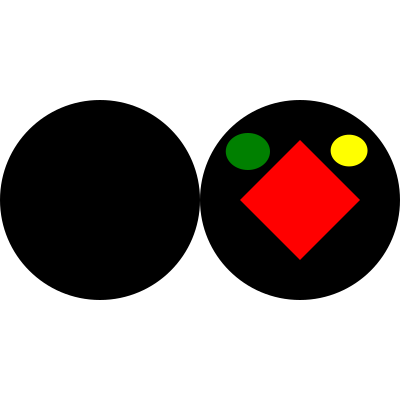

In [79]:
d = draw.Drawing(400, 400)

icon = load_svg_layers_normalized("rect1.svg", n_layers=4)

d.append(place_svg(icon, 100, 200, 200, fill=grad))
d.append(place_svg(icon, 300, 200, 200))

d.save_svg("result.svg")
d

4


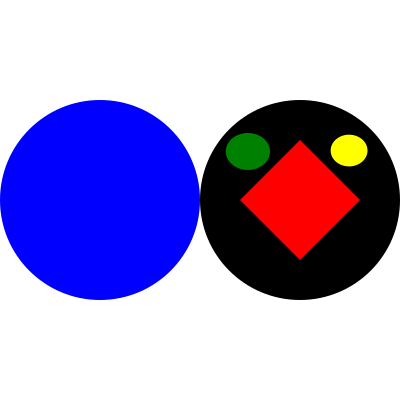

In [92]:
import drawsvg as draw

rg = draw.RadialGradient(
    cx="50%", cy="50%", r="50%"
)
rg.add_stop(0, "red")
rg.add_stop(1, "blue")
d.append(rg)

d = draw.Drawing(400, 400)

icon = load_svg_layers_normalized("rect1.svg", n_layers=4)

d.append(place_svg(icon, 100, 200, 200, fill=rg))
d.append(place_svg(icon, 300, 200, 200))

d.save_svg("result.svg")
d

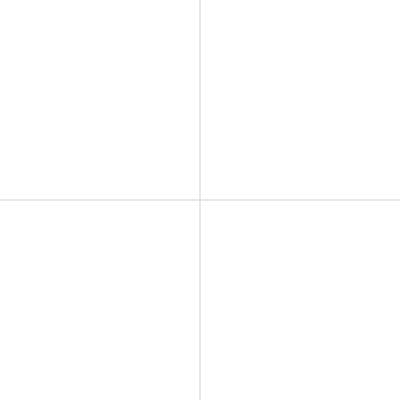

In [102]:
import drawsvg as draw
from svgelements import SVG
import copy


# ------------------------------------------------------------
# SVG LOADING + LAYER EXTRACTION
# ------------------------------------------------------------

def get_layers(svg):
    """Extract only Inkscape layers: <g id="layerX">"""
    layers = []
    for elem in svg.elements():
        if elem.__class__.__name__ == "Group":
            if getattr(elem, "id", "").startswith("layer"):
                layers.append(elem)
    return layers


def compute_bbox(elements):
    xmin = ymin = float("inf")
    xmax = ymax = float("-inf")

    for elem in elements:
        if not hasattr(elem, "bbox"):
            continue
        try:
            x0, y0, x1, y1 = elem.bbox()
        except Exception:
            continue

        xmin = min(xmin, x0)
        ymin = min(ymin, y0)
        xmax = max(xmax, x1)
        ymax = max(ymax, y1)

    if xmin == float("inf"):
        raise ValueError("No drawable geometry found")

    return xmin, ymin, xmax, ymax


def build_normalization_transform(bbox):
    xmin, ymin, xmax, ymax = bbox
    cx = 0.5 * (xmin + xmax)
    cy = 0.5 * (ymin + ymax)
    scale = 1.0 / (xmax - xmin)
    return scale, cx, cy


def render_layer(layer, scale, cx, cy):
    """Render layer without destroying SVG semantics"""
    g = draw.Group(
        transform=f"scale({scale}) translate({-cx},{-cy})"
    )

    for elem in layer:
        if hasattr(elem, "d"):
            g.append(
                draw.Path(
                    d=elem.d(),
                    fill=getattr(elem, "fill", "none"),
                    stroke=getattr(elem, "stroke", "none"),
                )
            )

    return g


def load_svg_layers(filename, n_layers=1):
    svg = SVG.parse(filename)
    layers = get_layers(svg)

    if not layers:
        raise ValueError("No layers found")

    bbox = compute_bbox(layers[0])  # normalize using first layer only
    scale, cx, cy = build_normalization_transform(bbox)

    out = draw.Group()

    for layer in layers[:n_layers]:
        out.append(render_layer(layer, scale, cx, cy))

    return out


# ------------------------------------------------------------
# PLACE SVG WITH OPTIONAL COLOR OVERRIDE
# ------------------------------------------------------------

def place_svg(svg_group, x, y, width, fill=None, stroke=None):
    """
    Place a normalized SVG instance.
    Supports:
      - solid colors
      - gradient references like "url(#id)"
    """

    g = draw.Group(
        transform=f"translate({x},{y}) scale({width})"
    )

    def apply(elem):
        if isinstance(elem, draw.Path):
            return draw.Path(
                d=elem.args["d"],
                fill=fill if fill is not None else elem.args.get("fill", "none"),
                stroke=stroke if stroke is not None else elem.args.get("stroke", "none"),
            )

        if isinstance(elem, draw.Group):
            ng = draw.Group()
            for c in elem.children:
                ng.append(apply(c))
            return ng

        return elem

    for child in svg_group.children:
        g.append(apply(child))

    return g


# ------------------------------------------------------------
# GRADIENT HELPERS (IMPORTANT PART)
# ------------------------------------------------------------

def make_radial_gradient(gradient_id="rg1"):
    """Create a radial gradient usable via url(#rg1)"""
    rg = draw.RadialGradient(cx="50%", cy="50%", r="50%" )
    rg.add_stop(0, "red")
    rg.add_stop(1, "blue")
    return rg


# ------------------------------------------------------------
# EXAMPLE USAGE
# ------------------------------------------------------------

d = draw.Drawing(400, 400)

# reference guides
d.append(draw.Line(0, 200, 400, 200, stroke="lightgray"))
d.append(draw.Line(200, 0, 200, 400, stroke="lightgray"))

# load SVG layers
icon = load_svg_layers("rect1.svg", n_layers=4)

# create gradient (MUST be added to drawing)
rg = make_radial_gradient("rg1")
d.append(rg)

# place icons
d.append(place_svg(icon, 100, 200, 80))
d.append(place_svg(icon, 200, 200, 120, fill="url(#rg1)"))
d.append(place_svg(icon, 300, 200, 160, fill="url(#rg1)"))

# export
d.save_svg("result.svg")
d